In [11]:
from langchain_ollama import ChatOllama
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_tavily import TavilySearch
from langgraph.graph.message import add_messages

In [12]:

tavily = TavilySearch(max_results=2)
tavily.invoke("what is gen ai?")

{'query': 'what is gen ai?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://guides.emich.edu/genAI',
   'title': 'What is Gen AI? - Generative AI - Research Guides at Eastern Michigan University',
   'content': '# Generative AI. This guide walks you through the considerations of using generative artificial intelligence (gen AI): selecting gen AI tools, best practices for using them, ethical considerations, and more. **Generative Artificial Intelligence** (gen AI, or generative AI) is a term used to describe a type of artificial intelligence that creates information (textual, visual, code, etc.) based on the training data and algorithms that have been programmed into it. Below are terms and definitions for concepts and processes often associated with Generative Artificial Intelligence. **Generative Artificial Intelligence (Generative AI or GAI)**\xa0is\xa0a type\xa0of artificial intelligence used to create content, including text, images, vid

In [13]:
llm = ChatOllama(model="llama3.2:3b")

In [42]:
response = llm.invoke("what is gen ai?")
response

AIMessage(content='Gen AI, also known as General Artificial Intelligence (AGI), refers to a hypothetical future type of artificial intelligence that possesses the ability to understand, learn, and apply knowledge across a wide range of tasks, similar to human intelligence. The term "General" denotes that it would be able to perform any intellectual task that humans can.\n\nGen AI is often described as a superintelligent AI system that can:\n\n1. **Understand natural language**: Gen AI would be able to comprehend and generate human-like language with ease.\n2. **Reason and learn**: It would be able to reason, learn from experience, and adapt to new situations.\n3. **Apply knowledge across domains**: Gen AI could apply its knowledge in various fields, such as science, technology, art, and more.\n4. **Make decisions and take actions**: It would be able to make informed decisions and take actions based on that decision-making process.\n\nThe ultimate goal of developing Gen AI is to create 

In [43]:
print(response.content)

Gen AI, also known as General Artificial Intelligence (AGI), refers to a hypothetical future type of artificial intelligence that possesses the ability to understand, learn, and apply knowledge across a wide range of tasks, similar to human intelligence. The term "General" denotes that it would be able to perform any intellectual task that humans can.

Gen AI is often described as a superintelligent AI system that can:

1. **Understand natural language**: Gen AI would be able to comprehend and generate human-like language with ease.
2. **Reason and learn**: It would be able to reason, learn from experience, and adapt to new situations.
3. **Apply knowledge across domains**: Gen AI could apply its knowledge in various fields, such as science, technology, art, and more.
4. **Make decisions and take actions**: It would be able to make informed decisions and take actions based on that decision-making process.

The ultimate goal of developing Gen AI is to create a machine that can:

1. **So

In [16]:
def multiply(a:int, b:int)->int:
    """Multiply a and b
    a : int the firat value
    b: int the second value

    return a*b
    """
    return a*b

In [17]:
tools = [tavily,multiply]

llm_with_tool = llm.bind_tools(tools)

In [19]:
from typing_extensions import TypedDict, Annotated
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [20]:
# Node definations

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

In [33]:
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# edge defining

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools",END)

graph = builder.compile()

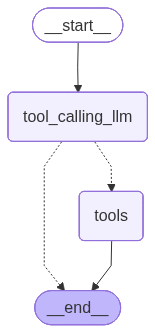

In [34]:
graph

In [38]:
response=graph.invoke({"messages":"what is share price of yesbank?"})

In [39]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is share price of yesbank?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ad98bb10-e48c-4ba1-9fae-642417e47821)
 Call ID: ad98bb10-e48c-4ba1-9fae-642417e47821
  Args:
    query: yes bank share price
    exclude_domains: None
    start_date: None
    time_range: None
    topic: finance
    end_date: None
    include_domains: None
    include_images: False
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "yes bank share price", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/quote/YESBANK.NS/history", "title": "Yes Bank Limited (YESBANK.NS) Stock Historical Prices & Data - Yahoo Finance", "content": "# Yes Bank Limited (YESBANK.NS). | Date | Open | High | Low | Close    Close price adjusted for 

In [36]:
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# edge defining

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools","tool_calling_llm")

graph_new = builder.compile()

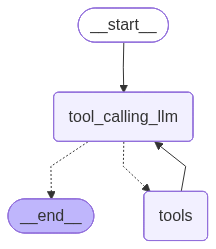

In [37]:
graph_new

In [40]:
response=graph_new.invoke({"messages":"what is share price of yesbank?"})

In [41]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is share price of yesbank?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (5fb2cb47-31c7-4126-8e61-8e921b1ed94d)
 Call ID: 5fb2cb47-31c7-4126-8e61-8e921b1ed94d
  Args:
    search_depth: None
    time_range: None
    topic: None
    end_date: None
    include_images: False
    start_date: None
    query: yes bank share price
    exclude_domains: None
    include_domains: None
================================= Tool Message =================================
Name: tavily_search

{"query": "yes bank share price", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bajajfinserv.in/investments/yesbank-share-price", "title": "Yes Bank Limited Share Price Today Live NSE/BSE", "content": "## Yes bank limited share price update. Stock price as on 19 May 2026 at 13:28 PM. As of the latest trading session, Yes Ba